In [27]:
import subprocess
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import scipy.optimize as so
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
import subprocess
from scipy.optimize import curve_fit
sns.set()
sns.set_context('paper', font_scale=1.2)

In [28]:
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################
# Path: Newsimulation.ipynb
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################

# Parse EnergyPlus datetime string
energyplus_install_dir=r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\EnergyPlusV9-6-0"
output_relative_directory =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation"
#idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\SmallOffice.idf"
#idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\backup_august_8_23_original_workingfortraining\SmallOffice.idf"
idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\backup_august_8_23_original_workingfortraining\SmallOffice.idf"
#idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\Backup_13_july_2025\editable\SmallOffice.idf"
#epw_relative_filepath =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\USA_WY_Casper-Natrona.County.Intl.AP.725690_US.Normals.2006-2020.epw"
epw_relative_filepath =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\USA_CO_Denver.Intl.AP.725650_TMY3.epw"
#epw_relative_filepath =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\USA_CO_Golden-NREL.724666_TMY3.epw"

def run_command(cmd_string, capture_output=False):
    # sourcery skip: raise-specific-error
    result = subprocess.run(cmd_string, capture_output=capture_output)
    if result.returncode != 0:
        raise Exception(f'Command failed with return code: {result.returncode}')
    print('---RETURNCODE---\n', result.returncode, '(SUCCESS)')
    return result



# building command string
cl_st=(f'"{energyplus_install_dir}\\energyplus" '
       + '--readvars '
       + f'--output-directory "{output_relative_directory}" '
       + f'--weather "{epw_relative_filepath}" '
       + f'"{idf_relative_filepath}"'
      )


# running the simulation
run_command(cl_st)

---RETURNCODE---
 0 (SUCCESS)


CompletedProcess(args='"D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\EnergyPlusV9-6-0\\energyplus" --readvars --output-directory "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\validation" --weather "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\USA_CO_Denver.Intl.AP.725650_TMY3.epw" "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\backup_august_8_23_original_workingfortraining\\SmallOffice.idf"', returncode=0)

In [29]:
# function to parse EnergyPlus datetime string
def parse_energyplus_datetime_string(st, year=2021):
    st = st.strip()
    month, day = map(int, [st[:2], st[3:5]])
    hour = int(st[7:9]) if st[7:9] != '24' else 0
    minute = int(st[10:12])
    dt = pd.Timestamp(year, month, day, hour, minute)
    return dt if st[7:9] != '24' else dt + pd.Timedelta('1 day')

C:\Users\USER\AppData\Local\Temp\ipykernel_16012\715329555.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\eplusout.csv",


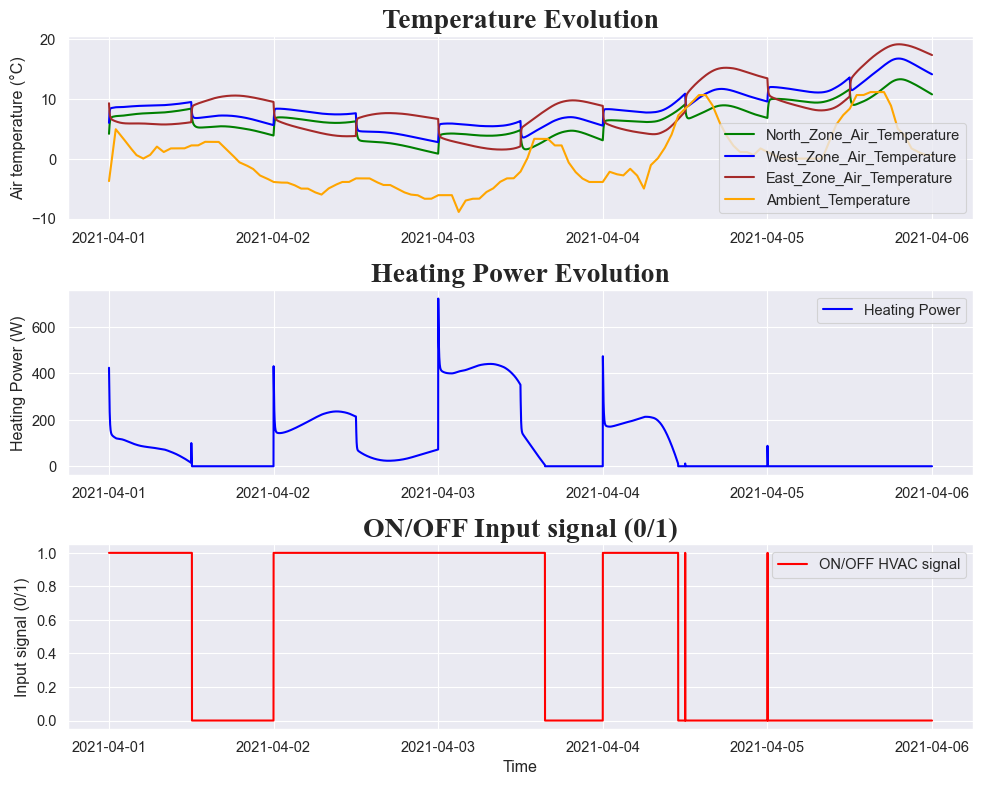

In [30]:
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################
# Plotting the results from the simulation
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################


# load simulation data
df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\eplusout.csv",
               parse_dates=[0],
               index_col=[0],
               date_parser=parse_energyplus_datetime_string
              )

rename_dict = {
    "NORTH ZONE:Zone Air Temperature [C](TimeStep)": "North_Zone_Air_Temperature", 
    "WEST ZONE:Zone Air Temperature [C](TimeStep)": "West_Zone_Air_Temperature", 
    "EAST ZONE:Zone Air Temperature [C](TimeStep)": "East_Zone_Air_Temperature", 
    "Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)": "Ambient_Temperature", 
    "MAIN HEATING COIL 1:Heating Coil Heating Rate [W](TimeStep)": "Heating_Power", 
    "ZONE3TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z1",
    "ZONE1TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z2",
    "ZONE2TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z3",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "North_Zone_Solar_Rate",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "North_Zone_Solar_Energy",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "West_Zone_Solar_Rate",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "West_Zone_Solar_Energy",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "East_Zone_Solar_Rate",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "East_Zone_Solar_Energy",
    "Date/Time": "Time"
}
df.rename(columns=rename_dict, inplace=True)
time_steps = np.arange(len(df))
df['time_steps'] = time_steps


minutes_to_plot = 2592000  # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# create and modify Heating Input column
df['Heating Input'] = df['Heating_Power'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z1'] = df['Heating_Power_Z1'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z2'] = df['Heating_Power_Z2'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z3'] = df['Heating_Power_Z3'].apply(lambda x: 1 if x > 0 else 0).astype(int)

# Format the current date and time
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# Specify the path and filename and save the DataFrame to a new CSV file
file_path =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation"
filename = f"{file_path}imulation_results_{timestamp}.csv"
filename2 = r'D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\validation\Indoor_Temperatures2.csv'
# Specify the file path

df.to_csv(filename, index=False)
df.to_csv(filename2, index=False)


fig, axs = plt.subplots(3, 1, figsize=(10, 8), tight_layout=True)
minutes_to_plot = 2592000   # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# Plot T_int1, T_int2, T_int3, T_ext
for temp, color in zip(['North_Zone_Air_Temperature', 'West_Zone_Air_Temperature', 'East_Zone_Air_Temperature', 'Ambient_Temperature'], ['green', 'blue', 'brown', 'orange']):
    axs[0].plot(plot_data.index, plot_data[temp], color=color, linewidth=1.5, label=temp)
axs[0].set(ylabel='Temperature (°C)')
axs[0].legend(loc='best')
axs[0].set_ylabel('Air temperature (°C)')
axs[0].set_title('Temperature Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea1
axs[1].plot(plot_data.index, plot_data['Heating_Power'], color='blue', linewidth=1.5, label='Heating Power')
axs[1].set(ylabel='Heating Power (W)')
axs[1].legend(loc='best')
axs[1].set_ylabel('Heating Power (W)')
axs[1].set_title('Heating Power Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea2
axs[2].plot(plot_data.index, plot_data['Heating Input'], color='red', linewidth=1.5, label='ON/OFF HVAC signal')
axs[2].set(xlabel='Time', ylabel='P_hea2')
axs[2].legend(loc='best')
axs[2].set_ylabel('Input signal (0/1)')
axs[2].set_title('ON/OFF Input signal (0/1)', fontname="Times New Roman", size=20, fontweight="bold")

plt.show()

plt.show()

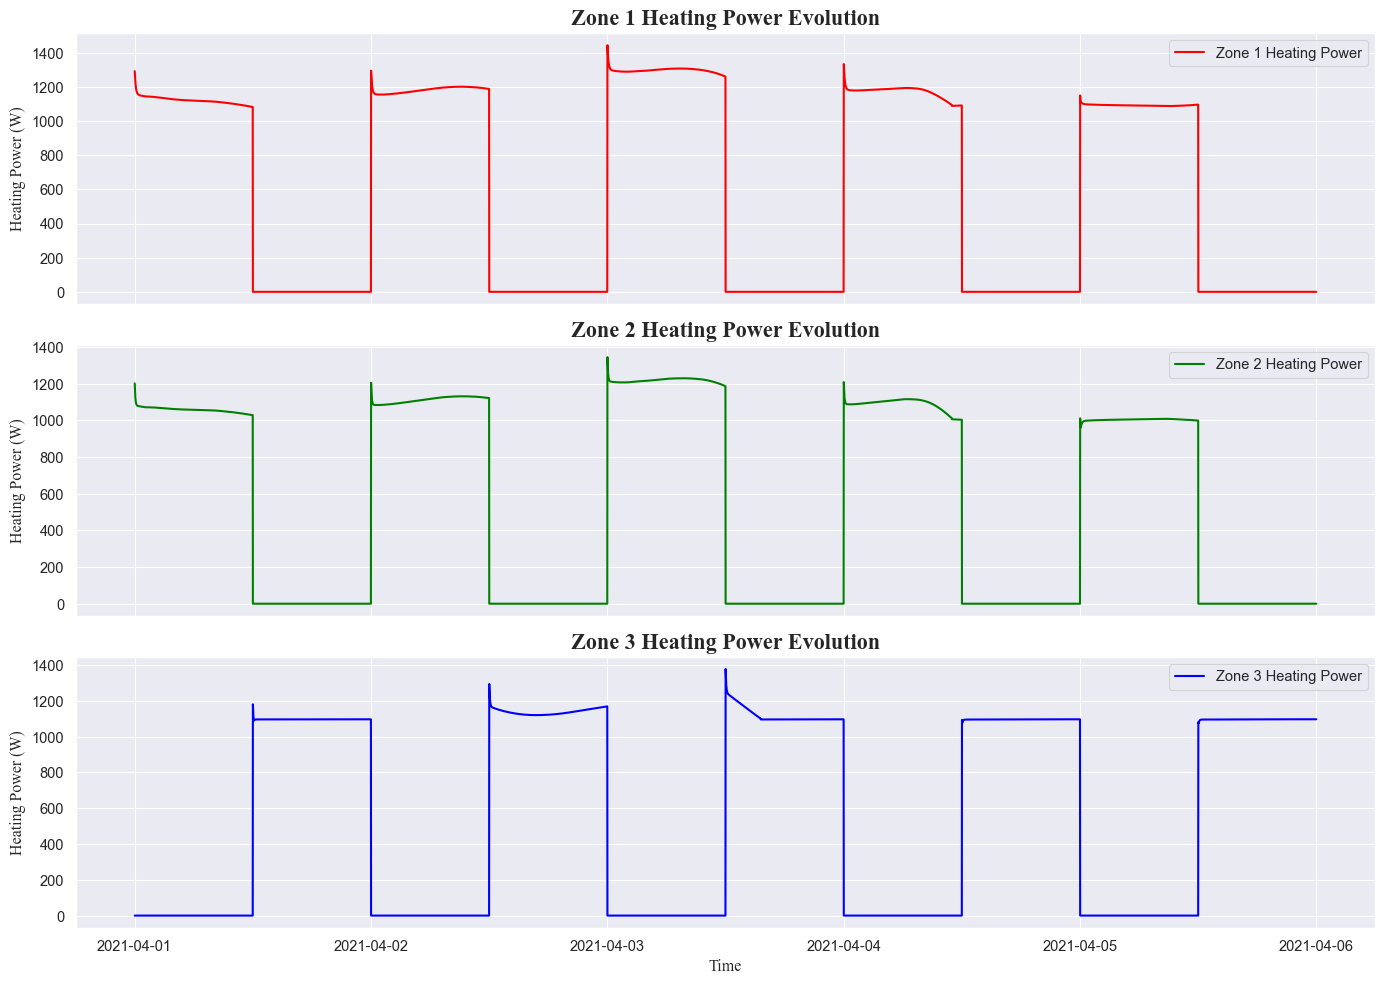

In [31]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
# Plot for Zone 1
axs[0].plot(df.index, df['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='best')
axs[0].set_title('Zone 1 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 2
axs[1].plot(df.index, df['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='best')
axs[1].set_title('Zone 2 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 3
axs[2].plot(df.index, df['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='best')
axs[2].set_title('Zone 3 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

plt.tight_layout()
plt.show()

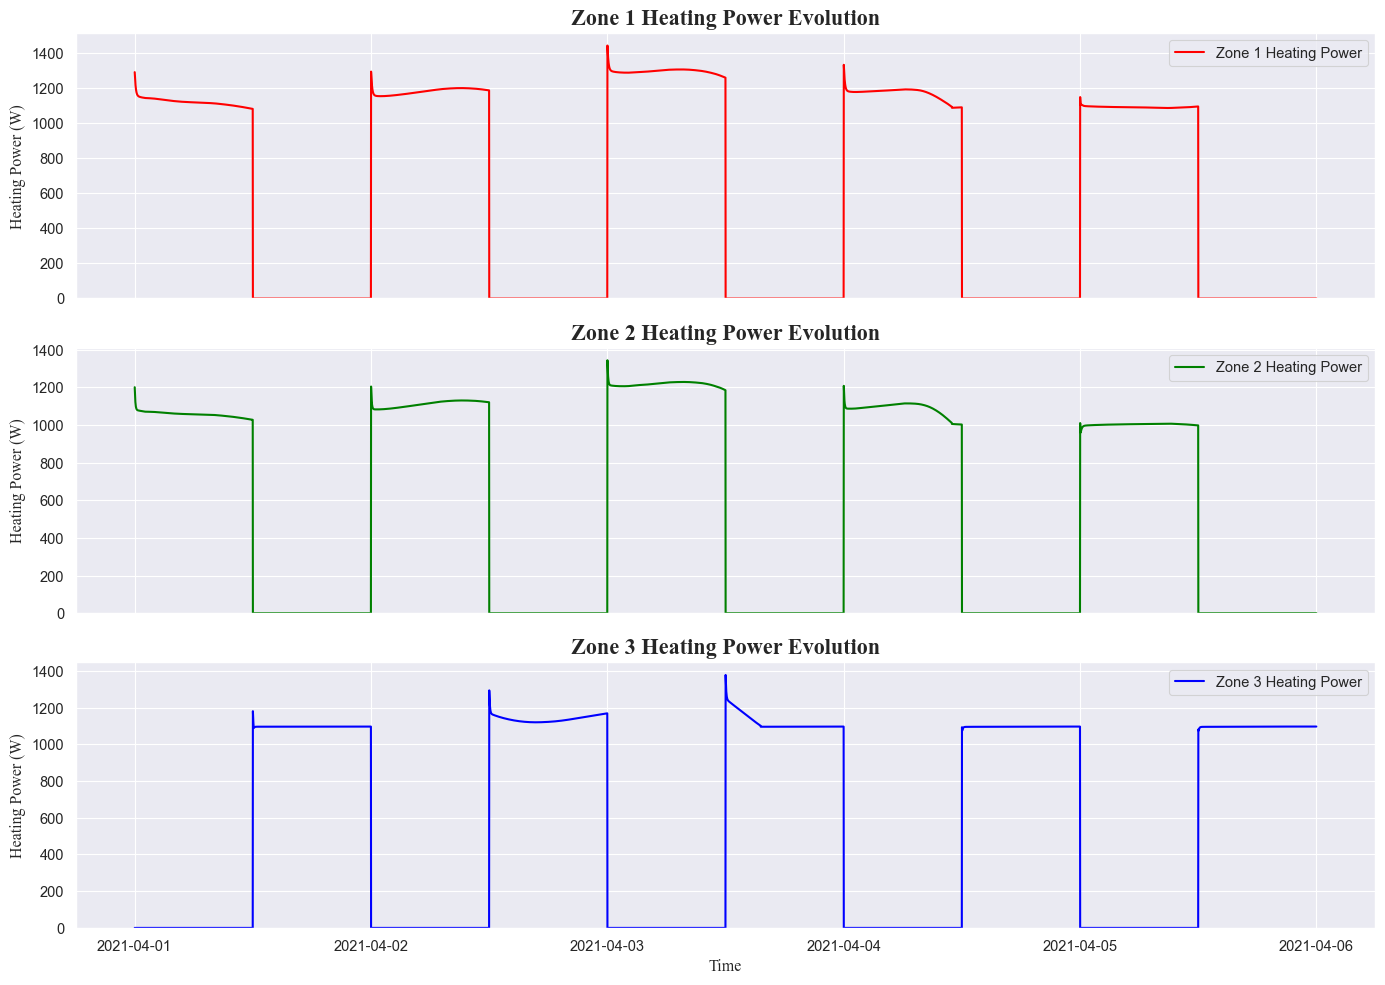

In [32]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot for Zone 1
axs[0].plot(df.index, df['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='best')
axs[0].set_title('Zone 1 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")
axs[0].set_ylim(bottom=0)

# Plot for Zone 2
axs[1].plot(df.index, df['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='best')
axs[1].set_title('Zone 2 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")
axs[1].set_ylim(bottom=0)

# Plot for Zone 3
axs[2].plot(df.index, df['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='best')
axs[2].set_title('Zone 3 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")
axs[2].set_ylim(bottom=0)

plt.tight_layout()
plt.show()


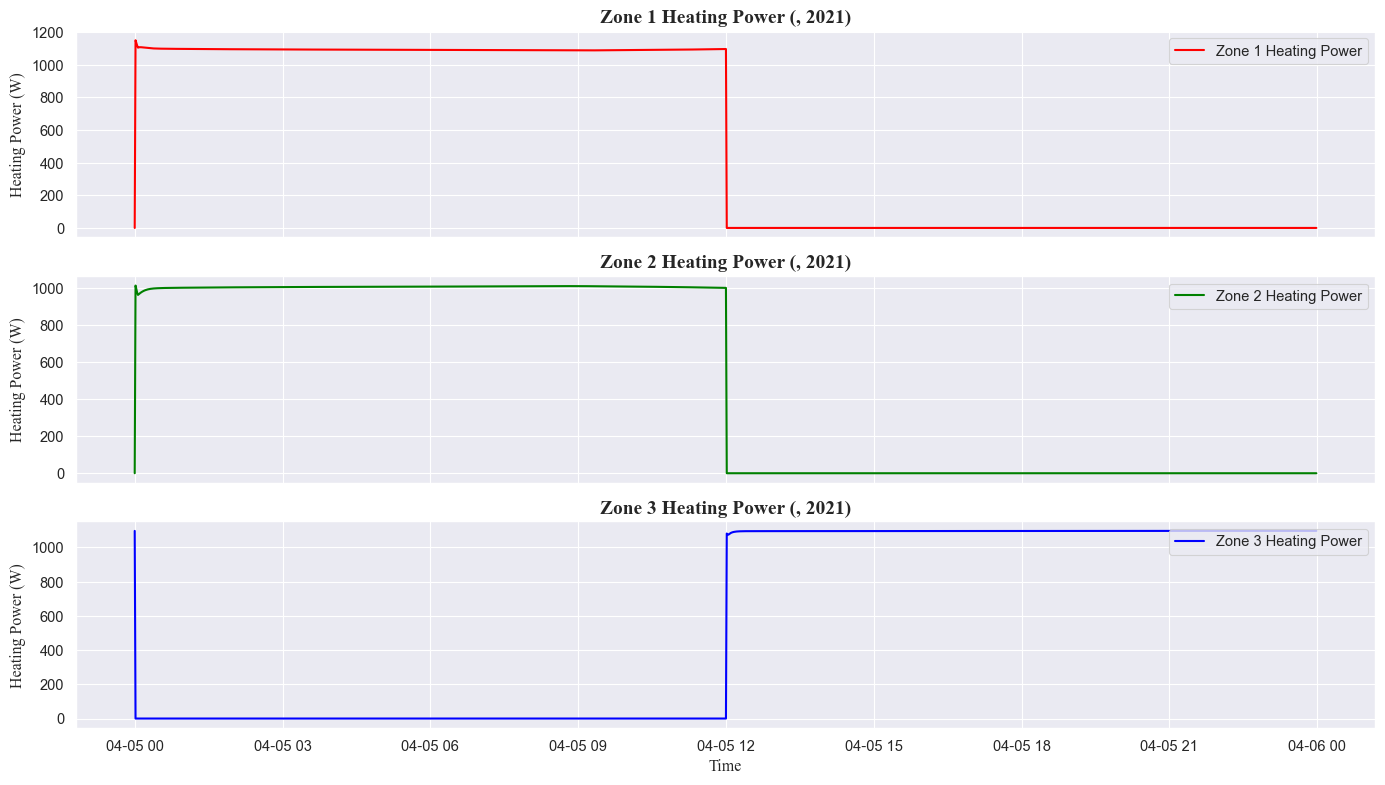

In [36]:
import matplotlib.pyplot as plt

# Make sure index is datetime
df.index = pd.to_datetime(df.index)

# Select 1 day (adjust date as needed)
one_day = df.loc['2021-4-5']

# Plot
fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Zone 1
axs[0].plot(one_day.index, one_day['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='upper right')
axs[0].set_title('Zone 1 Heating Power (, 2021)', fontname="Times New Roman", fontsize=14, fontweight="bold")

# Zone 2
axs[1].plot(one_day.index, one_day['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='upper right')
axs[1].set_title('Zone 2 Heating Power (, 2021)', fontname="Times New Roman", fontsize=14, fontweight="bold")

# Zone 3
axs[2].plot(one_day.index, one_day['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='upper right')
axs[2].set_title('Zone 3 Heating Power (, 2021)', fontname="Times New Roman", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


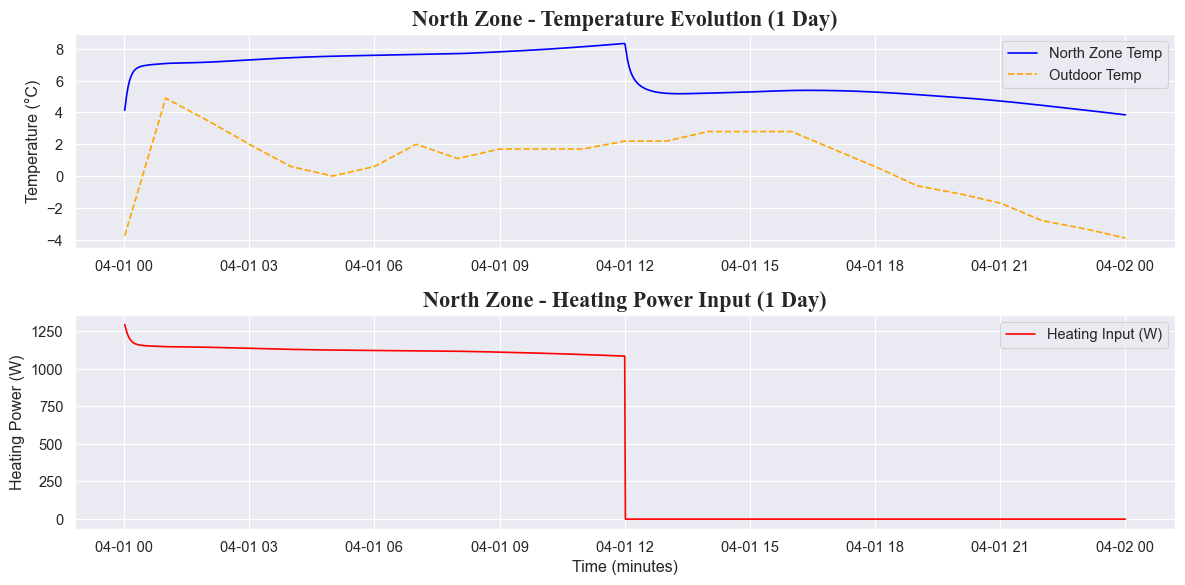

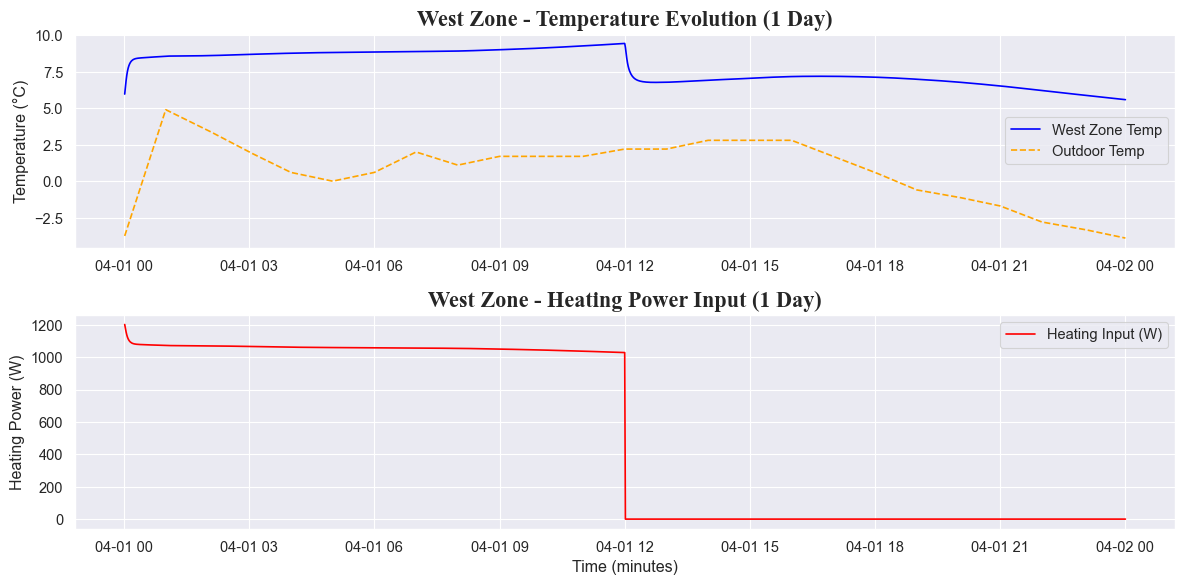

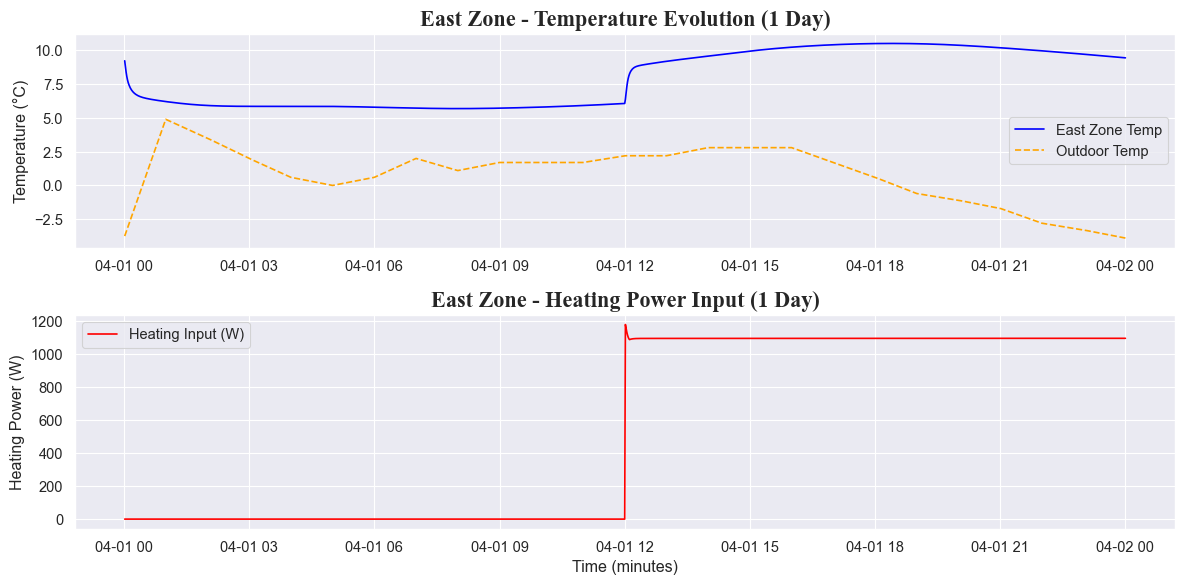

In [38]:
import matplotlib.pyplot as plt

# Define how many minutes = 1 day
minutes_in_one_day = 1440  

# Ensure data is long enough/
if len(df) >= minutes_in_one_day:
    day_data = df.iloc[:minutes_in_one_day]
else:
    day_data = df  # Use what we have

zones = [
    ('North_Zone_Air_Temperature', 'Heating_Power_Z1', 'North Zone'),
    ('West_Zone_Air_Temperature', 'Heating_Power_Z2', 'West Zone'),
    ('East_Zone_Air_Temperature', 'Heating_Power_Z3', 'East Zone'),
]

for temp_col, power_col, zone_name in zones:
    fig, axs = plt.subplots(2, 1, figsize=(12, 6), tight_layout=True)

    # Temperature subplot
    axs[0].plot(day_data.index, day_data[temp_col], label=f'{zone_name} Temp', color='blue')
    axs[0].plot(day_data.index, day_data['Ambient_Temperature'], label='Outdoor Temp', color='orange', linestyle='--')
    axs[0].set_ylabel('Temperature (°C)')
    axs[0].set_title(f'{zone_name} - Temperature Evolution (1 Day)', fontname="Times New Roman", fontsize=16, fontweight='bold')
    axs[0].legend()

    # Heating power input subplot
    axs[1].plot(day_data.index, day_data[power_col], label='Heating Input (W)', color='red')
    axs[1].set_ylabel('Heating Power (W)')
    axs[1].set_xlabel('Time (minutes)')
    axs[1].set_title(f'{zone_name} - Heating Power Input (1 Day)', fontname="Times New Roman", fontsize=16, fontweight='bold')
    axs[1].legend()

    plt.show()


C1: 3829.6
C2: 2257.4
C3: 4509.3
K12: 118.4
K10: 115.6
K23: 184.3
K20: 23.3
K30: 55.6
RMSE for Zone 1: 2.04
RMSE for Zone 2: 0.49
RMSE for Zone 3: 1.06
7200
7200
7200


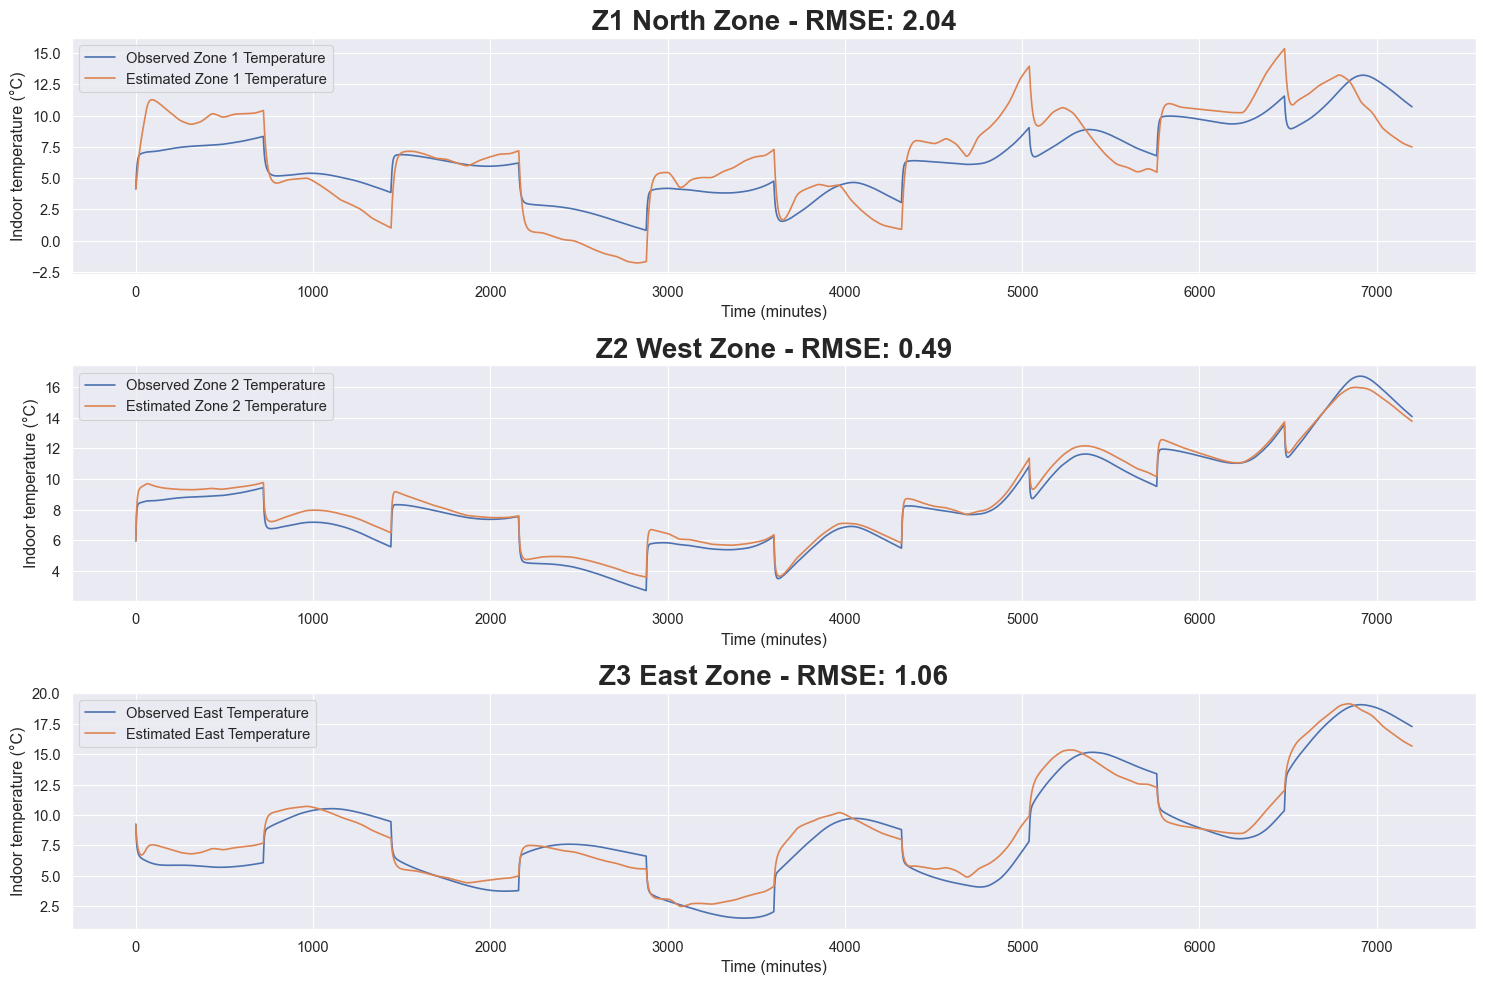

In [39]:

# Load the parameters from CSV file
#parameters_path = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"
#parameters_df = pd.read_csv(parameters_path)
'''
# Extract the identified parameters
C1 = parameters_df['C1'].values[0]
C2 = parameters_df['C2'].values[0]
C3 = parameters_df['C3'].values[0]
K12 = parameters_df['K12'].values[0]
K10 = parameters_df['K10'].values[0]
K23 = parameters_df['K23'].values[0]
K20 = parameters_df['K20'].values[0]
K30 = parameters_df['K30'].values[0]
'''
#C1  =  6500.0
#C2  =  2708.53074865442
#C3  =  14685.8219174825
#K12 =  387.49751157417643
#K10 =  300.71672918968085
#K23 =  106.61162090281734
#K20 =  20.0
#K30 =  97.6245196026192
#D1  =  0.3
#D2  =  1.5414887566287894
# Denver configuration


#10% WINDOWS
#K12 = 767.7
#K23 = 196.6
#K10 = 240.3
#K20 = 0.0
#K30 = 83.4
#C1 = 5526.0
#C2 = 1281.8
#C3 = 4048.8
#D1 = 0.0
#D2 = 1.6

#OFFSHCEDULE WINDOWS
#K12 = 725.5
#K23 = 194.3
#K10 = 231.0
#K20 = 0.0
#K30 = 86.5
#C1 = 5493.9
#C2 = 1326.2
#C3 = 4069.1
#D1 = 0
#D2 = 2.107592904066596

#Open `100%windows
#K12 = 827.7
#K23 = 197.7
#K10 = 272.8
#K20 = 60.2
#K30 = 64.3
#C1 = 5503.3
#C2 = 1130.7
#C3 = 4036.1
#D1 = 0.0
#D2 = 0.0

#july month 10%
#K12 = 267.0
#K23 = 146.4
#K10 = 89.9
#K20 = 41.7
#K30 = 48.1
#C1 = 3933.7
#C2 = 2121.2
#C3 = 5295.9
#D1 = 5.8547202812626115e-24
#D2 = 0.6957880553777965


#july fully window opn
#K12 = 183.1
#K23 = 139.2
#K10 = 102.8
#K20 = 93.0
#K30 = 29.9
#C1 = 4568.5
#C2 = 1942.8
#C3 = 5176.6
#D1 = 2.465190328815662e-32
#D2 = 1.232595164407831e-31

#july window 10% 0 angle
#K12 = 230.3
#K23 = 192.4
#K10 = 114.9
#K20 = 9.0
#K30 = 54.7
#C1 = 4097.1
#C2 = 1783.2
#C3 = 4015.3
#D1 = 1.7367561689345796e-26
#D2 = 0.04612226272218201

#bellingham
#K12 = 209.8
#K23 = 192.3
#K10 = 120.3
#K20 = 6.7
#K30 = 53.8
#C1 = 4206.1
#C2 = 1807.4
#C3 = 4036.8
#D1 = 4.40499929475413e-27
#D2 = 0.2256086403923423

#K12 = 247.5  
#K23 = 200.8  
#K10 = 236.3  
#K20 = 26.4  
#K30 = 86  
#C1 = 4100.7  
#C2 = 2187.7  
#C3 = 3750.3  
#D1 = 3.16e-30  
#D2 = 0.556775142

#K12 = 209.8  
#K23 = 192.3  
#K10 = 120.3  
#K20 = 6.7  
#K30 = 53.8  
#C1 = 4206.1  
#C2 = 1807.4  
#C3 = 4036.8  
#D1 = 4.40499929475413e-27  
#D2 = 0.2256086403923423


K12 = 118.4
K23 = 184.3
K10 = 115.6
K20 = 23.3
K30 = 55.6
C1  = 3829.6
C2  = 2257.4
C3  = 4509.3
D1  = 6.50E-28
D2  = 0.054922866


D3=0


# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")

# Load the data for temperature and heating power
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-09-41.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values
num_steps = len(time)
dt = np.median(np.diff(time))

# Extracting data
T_outdoor = df['Ambient_Temperature'].values 
zone1 = df['North_Zone_Air_Temperature'].values
zone2 = df['West_Zone_Air_Temperature'].values
zone3 = df['East_Zone_Air_Temperature'].values
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values


#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)

# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
# Recalculate RMSE for the sliced data
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")

minutes_to_plot = 8640

# Ensure that we have enough data to plot 200 minutes
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3

   
# Create a DataFrame
plot_T_outdoor = T_outdoor[:minutes_to_plot] if len(time) > minutes_to_plot else T_outdoor

data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': plot_T_outdoor
}

print(len(plot_time))
print(len(plot_zone1))
print(len(T_outdoor))
df = pd.DataFrame(data)

# Save to CSV
df.to_csv(r'D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\validation.csv', index=False)









plt.figure(figsize=(15, 10))

# North Zone
plt.subplot(3, 1, 1)
plt.plot(time, zone1, label='Observed Zone 1 Temperature')
plt.plot(time, estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z1 North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(time, zone2, label='Observed Zone 2 Temperature')
plt.plot(time, estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z2 West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(time, zone3, label='Observed East Temperature')
plt.plot(time, estimated_zone3, label='Estimated East Temperature')
#plt.plot(time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"Z3 East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(15, 10))

# North Zone
plt.subplot(3, 1, 1)
plt.plot(time, zone1, label='Observed Zone 1 Temperature', color='green')
plt.plot(time, estimated_zone1, label='Estimated Zone 1 Temperature', linestyle='--', color='green')
plt.plot(time, T_outdoor, label='Outdoor Temperature', color='orange')
plt.legend()
plt.title(f"Z1 North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(time, zone2, label='Observed Zone 2 Temperature', color='blue')
plt.plot(time, estimated_zone2, label='Estimated Zone 2 Temperature', linestyle='--', color='blue')
plt.plot(time, T_outdoor, label='Outdoor Temperature', color='orange')
plt.legend()
plt.title(f"Z2 West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(time, zone3, label='Observed Zone 3 Temperature', color='brown')
plt.plot(time, estimated_zone3, label='Estimated Zone 3 Temperature', linestyle='--', color='brown')
plt.plot(time, T_outdoor, label='Outdoor Temperature', color='orange')
plt.legend()
plt.title(f"Z3 East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()


In [ ]:
D1

In [ ]:
import pandas as pd

# Parameter names
params = ['C1', 'C2', 'C3', 'K12', 'K10', 'K23', 'K20', 'K30', 'D1', 'D2']

# Initial guesses
initial_guess = [
    3661.9, 2754.2, 2456.7,
    142.0, 178.9, 522.6,
    113.8, 123.5, 1.1, 1.7
]

# Bounds (updated lower bound for D1 to 0.3)
bounds = [
    (1e-3, None), (1e-3, None), (1e-3, None),
    (1e-3, None), (1e-3, None), (1e-3, 1000),
    (1e-3, None), (1e-3, None), (0.3, 2), (1e-3, 2)
]

# Optimized values with bounds (updated)
optimized = [
    3627.7092102064485, 2346.9014532855253, 2138.6408309258795,
    351.813982764643, 187.17815747399163, 999.999999886755,
    15.2220185324077, 135.51523474203427, 0.3000000019728098, 1.521942405533983
]

# Optimized values without bounds
optimized_no_bounds = [
    3645.1494131494273, 3438.1488874774095, 3378.9046445570634,
    382.6749038243343, 189.96135924354493, 5461.820792786003,
    0.0010000865397175032, 351.4322676657587, 0.0010000023363694417, 6.443662232675653
]

# Create DataFrame
df = pd.DataFrame({
    'Parameter': params,
    'Initial Guess': initial_guess,
    'Lower Bound': [b[0] for b in bounds],
    'Upper Bound': [b[1] if b[1] is not None else '∞' for b in bounds],
    'Optimized (Bounds)': optimized,
    'Optimized (No Bounds)': optimized_no_bounds
})

# Display
print(df.to_string(index=False))


In [ ]:
# Define number of minutes in a day
minutes_per_day = 1440

# Total number of days in the data
num_days = int(np.ceil(time[-1] / minutes_per_day))

print(f"Total days in simulation: {num_days}")

for day in range(num_days):
    # Get the time window for this day
    start_time = day * minutes_per_day
    end_time = (day + 1) * minutes_per_day

    # Create a mask to select the indices for this day
    mask = (time >= start_time) & (time < end_time)
    
    if not np.any(mask):
        continue  # Skip if no data in this window

    day_time = time[mask] - start_time  # Normalize to 0-1440 minutes
    day_zone1 = zone1[mask]
    day_estimated_zone1 = estimated_zone1[mask]
    day_zone2 = zone2[mask]
    day_estimated_zone2 = estimated_zone2[mask]
    day_zone3 = zone3[mask]
    day_estimated_zone3 = estimated_zone3[mask]

    # Plot
    plt.figure(figsize=(15, 10))

    # North Zone
    plt.subplot(3, 1, 1)
    plt.plot(day_time, day_zone1, label='Observed Zone 1')
    plt.plot(day_time, day_estimated_zone1, label='Estimated Zone 1')
    plt.legend()
    plt.title(f"Day {day + 1} - North Zone", fontsize=16)
    plt.xlabel('Time of Day (minutes)')
    plt.ylabel('Temperature (°C)')

    # West Zone
    plt.subplot(3, 1, 2)
    plt.plot(day_time, day_zone2, label='Observed Zone 2')
    plt.plot(day_time, day_estimated_zone2, label='Estimated Zone 2')
    plt.legend()
    plt.title(f"Day {day + 1} - West Zone", fontsize=16)
    plt.xlabel('Time of Day (minutes)')
    plt.ylabel('Temperature (°C)')

    # East Zone
    plt.subplot(3, 1, 3)
    plt.plot(day_time, day_zone3, label='Observed Zone 3')
    plt.plot(day_time, day_estimated_zone3, label='Estimated Zone 3')
    plt.legend()
    plt.title(f"Day {day + 1} - East Zone", fontsize=16)
    plt.xlabel('Time of Day (minutes)')
    plt.ylabel('Temperature (°C)')

    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Define number of minutes in a day
minutes_per_day = 1440

# Total number of days in the data
num_days = int(np.ceil(time[-1] / minutes_per_day))

print(f"Total days in simulation: {num_days}")

# Colors for consistency
zone_colors = ['green', 'blue', 'brown']
zone_names = ['Z1 North', 'Z2 West', 'Z3 East']
observed_data = [zone1, zone2, zone3]
estimated_data = [estimated_zone1, estimated_zone2, estimated_zone3]
heating_power_data = [U1, U2, U3]

for day in range(num_days):
    # Time window for this day
    start_time = day * minutes_per_day
    end_time = (day + 1) * minutes_per_day

    # Mask to select the day's data
    mask = (time >= start_time) & (time < end_time)
    if not np.any(mask):
        continue

    day_time = (time[mask] - start_time) / 60  # x-axis in hours (0–24)

    T_outdoor_day = T_outdoor[mask]

    # Create figure
    fig, axs = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(f"Day {day + 1} - Temperature and Heating Power Evolution", fontsize=22, fontweight='bold', fontname="Times New Roman")

    for i, ax in enumerate(axs):
        obs = observed_data[i][mask]
        est = estimated_data[i][mask]
        heat = heating_power_data[i][mask]

        color = zone_colors[i]
        label_zone = f"{zone_names[i]}_Zone_Air_Temperature"

        # Plot observed zone temperature
        ax.plot(day_time, obs, color=color, linewidth=1.5, label=f"Observed {zone_names[i]} Zone Temperature")
        
        # Plot estimated zone temperature
        ax.plot(day_time, est, color=color, linestyle='--', linewidth=1.5, label=f"Estimated {zone_names[i]} Zone Temperature")
        
        # Plot outdoor temperature
        ax.plot(day_time, T_outdoor_day, color='orange', linewidth=1.5, label='Outdoor Temperature')

        ax.set_ylabel('Temperature (°C)', fontsize=14, fontname="Times New Roman")
        ax.set_title(f"{zone_names[i]} Zone", fontsize=18, fontweight='bold', fontname="Times New Roman")

        # Secondary y-axis for Heating Power
        ax2 = ax.twinx()
        ax2.plot(day_time, heat, color='red', linewidth=1.5, label='Heating Power')
        ax2.set_ylabel('Heating Power (W)', fontsize=14, fontname="Times New Roman", color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        # Legends
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=12)

    axs[-1].set_xlabel('Time of Day (hours)', fontsize=16, fontname="Times New Roman")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
